<a href="https://colab.research.google.com/github/dogukan-findik/Credit-Card-Fraud-Deteciton/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.callbacks import EarlyStopping




In [ ]:
#tekrarlanabilirlik için rastgelelik saibtleyelim
np.random.seed(42)
tf.random.set_seed(42)

#veri setini yükleme
df=pd.read_csv("creditcard.csv")
df.head()

#sınıf dağılımını kontrol edelim
print("veri boyutu",df.shape)
print("\n Sınıf Dağılımı (0:Normal 1:fraud):")
print(df["Class"].value_counts())

veri boyutu (284807, 31)

 Sınıf Dağılımı (0:Normal 1:fraud):
Class
0    284315
1       492
Name: count, dtype: int64


HÜCRE ÖN İŞLEME VE VERİYİ MANTIKSAL KÜMELERE AYIRMA

In [ ]:
df=df.drop(['Time'], axis=1) # time sütunu görecei ve işe yaramıyor çıkart tablodan

#tutar amount değişkeni pca değişkenleri gibi standartlaşıtırılmamış skaler ile onu da ölçeklemeliyiz
scaler=StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

normal_data=df[df['Class']==0]
fraud_data=df[df['Class']==1]

#Normal veriyi eiğitim ve test olarak ikiye böl
#eğitim sırasında fraud görülmeyecek
train_normal,test_normal=train_test_split(normal_data,test_size=0.2,random_state=42)

#doğrulama için eğitim verisinden bir parça daha alıyoruz
train_normal, val_normal = train_test_split(train_normal, test_size=0.2, random_state=42)

#test kümesine fraud ve test verilerini ekilyoruz
test_data=pd.concat([test_normal,fraud_data])

# Model girdileri için 'Class' sütununu çıkarıyoruz (Autoencoder için x_girdi = y_hedef)
X_Train=train_normal.drop(['Class'],axis=1).values
X_val=val_normal.drop(['Class'],axis=1).values

#TEST DEĞERLENDİRMESİ İÇİN ÖZELLİKLERİ VE GERÇEK ETİKETLERİ SAKLIYORUZ
X_test=test_data.drop(['Class'],axis=1).values
Y_test=test_data['Class'].values

print(f"Eğitim verisi boyutu : {X_Train.shape}")
print(f"Doğrulama verisi boyutu : {X_val.shape}")
print(f"Test verisi boyutu : {X_test.shape} (Normal: {len(test_normal)}, Fraud: {len(fraud_data)})")

Eğitim verisi boyutu : (181961, 29)
Doğrulama verisi boyutu : (45491, 29)
Test verisi boyutu : (57355, 29) (Normal: 56863, Fraud: 492)


3. Hücre: Autoencoder Mimarisi ve Model Eğitimi
Model 29 özniteliği alıp dar bir darboğaza (bottleneck) sıkıştıracak, ardından bu sıkışmış temsilden orijinal veriyi yeniden inşa etmeye çalışacak.

In [ ]:
input_dim = X_Train.shape[1] #29 öznitelik

#Giriş Katmanı
input_layer = Input(shape=(input_dim,))

#Kodlayıcı
encoded = Dense(20, activation="relu")(input_layer)
bottleneck = Dense(10, activation="relu")(encoded)

#Kodlayıcıdan Çıkış
decoded = Dense(20, activation="relu")(bottleneck)
output_layer = Dense(input_dim, activation="linear")(decoded)

#modeli birleştirelim
autoencoder=Model(inputs=input_layer,outputs=output_layer)

#Modeli Derleme:compile hatasını ölçmek için mse kullnıyourz
autoencoder.compile(optimizer='adam',loss='mse')

#early stooping ekleem overfitting ekleemk için
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

#Modeli eğitme
history=autoencoder.fit(
    X_Train,
    X_Train,
    epochs=72,
    batch_size=96,
    shuffle=True,
    verbose=1,
    validation_data=(X_val,X_val),
    callbacks=[early_stop]
)



Epoch 1/72
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4850 - val_loss: 0.3337
Epoch 2/72
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2990 - val_loss: 0.2817
Epoch 3/72
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2640 - val_loss: 0.2566
Epoch 4/72
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2440 - val_loss: 0.2429
Epoch 5/72
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2347 - val_loss: 0.2353
Epoch 6/72
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2283 - val_loss: 0.2302
Epoch 7/72
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2241 - val_loss: 0.2266
Epoch 8/72
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2207 - val_loss: 0.2231
Epoch 9/72
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2164 - val_loss: 0.2182
Epoch 10/72
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2122 - val_loss: 0.2138
Epoch 11/72
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2083 - val_loss: 0.2104
Epoch 12/72
1896/1896 ━━━━━━━━

Yeniden Yapılandırma Hatası ve Eşik Değeri (Threshold) Belirleme
Model eğitildikten sonra doğrulama kümesindeki normal işlemlerin hatalarını hesaplayıp kabul edilebilir bir sınır belirliyoruz.

1422/1422 ━━━━━━━━━━━━━━━━━━━━ 1s 763us/step
Eşik Değeri (Threshold): 0.9068


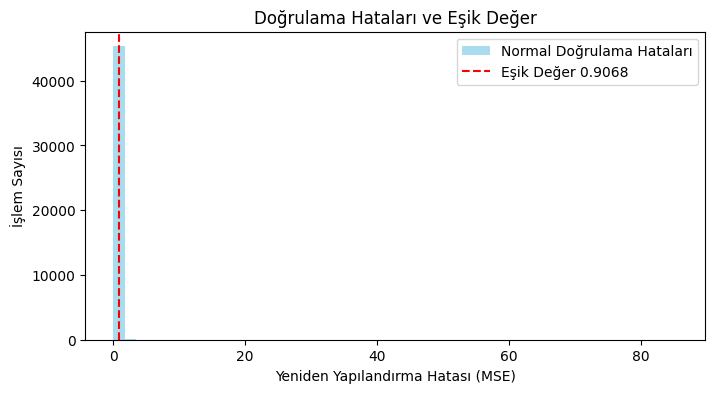

In [ ]:
#doğrulama ile tahmin ediyoruz
val_predictions=autoencoder.predict(X_val)

#hata hesaplama
val_mse=np.mean(np.power(X_val-val_predictions,2),axis=1)

## (%1'lik bir yalancı pozitif / false positive payı bırakıyoruz)
#normal işlemlerin %99 unun altında kalan kısmı hata değerlerini sınır olarak kabul ediyoruz
threshold = np.percentile(val_mse, 99)

print(f"Eşik Değeri (Threshold): {threshold:.4f}")

#hata dağılımını görselleştirelim
plt.figure(figsize=(8,4))
plt.hist(val_mse,bins=50,alpha=0.7,color='skyblue',label='Normal Doğrulama Hataları')
plt.axvline(threshold,color='red',linestyle='--',label=f'Eşik Değer {threshold:.4f}')
plt.xlabel('Yeniden Yapılandırma Hatası (MSE)')
plt.ylabel('İşlem Sayısı')
plt.title('Doğrulama Hataları ve Eşik Değer')
plt.legend()
plt.show()

Test Kümesinde Değerlendirme ve Performans Ölçümü

In [ ]:
#test kümesi için tahminleri üretelim
test_predictions=autoencoder.predict(X_test)

#hata hesaplama
test_mse=np.mean(np.power(X_test-test_predictions,2),axis=1)

#eğer hata eşik değerinden büyükse 1 küçükse 0 işaretle
y_pred=test_mse>threshold.astype(int)

#metrikleri hesaplayalım
print("sınıflandırma raporu")
print(classification_report(Y_test,y_pred,target_names=['Normal(0)','Fraud(1)']))

print("karmaşıklık matrisi confusion matrix")
cm=confusion_matrix(Y_test,y_pred)
print(f"Doğru Normal: {cm[0][0]}, Yakalanan Dolandırıcılık: {cm[1][1]}")
print(f"Yanlış Normal(false positive): {cm[0][1]}, kaçırılan dolandırıcılık (false negative): {cm[1][0]}")

print(f"\n Roc-Auc Skoru:{roc_auc_score(Y_test,test_mse):.4f}")

1793/1793 ━━━━━━━━━━━━━━━━━━━━ 1s 746us/step
sınıflandırma raporu
              precision    recall  f1-score   support

   Normal(0)       0.00      0.00      0.00     56863
    Fraud(1)       0.01      1.00      0.02       492

    accuracy                           0.01     57355
   macro avg       0.00      0.50      0.01     57355
weighted avg       0.00      0.01      0.00     57355

karmaşıklık matrisi confusion matrix
Doğru Normal: 0, Yakalanan Dolandırıcılık: 492
Yanlış Normal(false positive): 56863, kaçırılan dolandırıcılık (false negative): 0

 Roc-Auc Skoru:0.9350


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
